# PerÃ­odo vs amplitudÂ² â€” mediciÃ³n 30 (Â¿oscilador de Duffing amortiguado?)

AnÃ¡lisis **no paramÃ©trico** (cruces de nivel + medianas por ciclo; sin ajustes/filtros de la seÃ±al).

Idea: en un oscilador de Duffing la frecuencia depende de la amplitud,
$$\omega(A)\approx\omega_0\left(1+\tfrac{3}{8}\,\varepsilon\,A^2\right)\;\Rightarrow\;T(A)\approx T_0\left(1-\tfrac{3}{8}\,\varepsilon\,A^2\right).$$
Por eso, durante el *ring-down* (la amplitud decae sola), graficar **$T$ vs $A^2$** deberÃ­a dar
una recta si domina la no linealidad cÃºbica. Pendiente $>0$ â†’ resorte *blando* (softening);
pendiente $<0$ â†’ *endurecedor* (hardening); pendiente $\approx 0$ â†’ lineal (SHM).

**Definiciones pedidas:**
- amplitud $A$ = (pico a pico)/2, entre dos extremos consecutivos;
- perÃ­odo $T$ = 2 Ã— semiperÃ­odo (tiempo entre dos extremos consecutivos).

In [1]:
%matplotlib inline
import glob, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

STYLE = Path(r"C:\Users\lenny\OneDrive\Documents\FISICA\LABO 4\labo-4-2026\CAVENDISH\presentacion\windows7_aero.mplstyle")
plt.style.use(str(STYLE))

BASE   = Path(r"C:\Users\lenny\OneDrive\Documents\FISICA\LABO 4\labo-4-2026\CAVENDISH\Datos")
NOMBRE = "medicion30"
FACTOR_ESPEJO = 2.0          # el haz gira 2θ cuando el espejo gira θ

# Ventana de análisis. Poné WIN = None para usar TODA la medición.
WIN = (6000, 18000)

# ---- detección de picos (no paramétrica, robusta) ----
VENTANA_EXTREMO_S = 5.0      # ventana de mediana para ubicar cada extremo
BASE_LOCAL_S      = 480.0    # ventana de la mediana móvil del nivel de cruce (None = mediana global)
VENT_AMP_S        = 480.0    # ventana de la envolvente de amplitud (mediana de |señal - base|)
FRAC_BANDA        = 0.6      # zona muerta = FRAC_BANDA * amplitud reciente (envolvente)
K_BANDA           = 4.0      # piso de la zona muerta = K_BANDA * ruido(MAD)
print("Config OK")

Config OK


In [2]:
# ----- carga: concatena chunks en orden y cose reinicios de cÃ¡mara -> (t, x_mm, L_mm) -----
def parse_meta(path):
    d = {}
    for ln in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        ln = ln.strip()
        if "\t" in ln and not ln.startswith("#"):
            k, v = ln.split("\t", 1); d[k] = v
    return d

def load_medicion(nombre):
    carpeta = BASE / nombre
    meta = parse_meta(glob.glob(str(carpeta / "*_meta.txt"))[0])
    L_mm = float(meta["distancia_a_la_pantalla (cm)"]) * 10.0
    archivos = sorted(glob.glob(str(carpeta / "*_[0-9][0-9][0-9][0-9].txt")),
                      key=lambda f: int(re.search(r"_(\d+)\.txt$", f).group(1)))
    partes = []
    for f in archivos:
        try: a = pd.read_csv(f, sep="\t", header=None, dtype=float).values
        except Exception:
            try: a = np.atleast_2d(np.loadtxt(f))
            except Exception: continue
        if a.size and a.shape[1] >= 3: partes.append(np.atleast_2d(a[:, :3]))
    datos = np.concatenate(partes, axis=0)
    t, x = datos[:, 0].copy(), datos[:, 1].copy()
    dd = np.diff(t); dt_med = np.median(dd[dd > 0])
    for j in np.flatnonzero(dd < 0): t[j + 1:] += (t[j] - t[j + 1] + dt_med)
    return t, x, L_mm

def a_grados(v_mm, L_mm):
    """posiciÃ³n del haz [mm] -> Ã¡ngulo del pÃ©ndulo [grados] (palanca Ã³ptica)"""
    return np.degrees(np.arctan(v_mm / L_mm) / FACTOR_ESPEJO)

t, x_mm, L_mm = load_medicion(NOMBRE)
th = a_grados(x_mm, L_mm)
if WIN is not None:
    m = (t >= WIN[0]) & (t <= WIN[1]); t, th = t[m], th[m]
print(f"{NOMBRE}: {len(t)} muestras, {(t[-1]-t[0]):.0f} s analizados")

medicion30: 154809 muestras, 10441 s analizados


zona muerta: piso ±0.0049°  ->  ±[0.0218, 0.5023]° (∝ amplitud)   ->   62 extremos (31 máx, 31 mín)


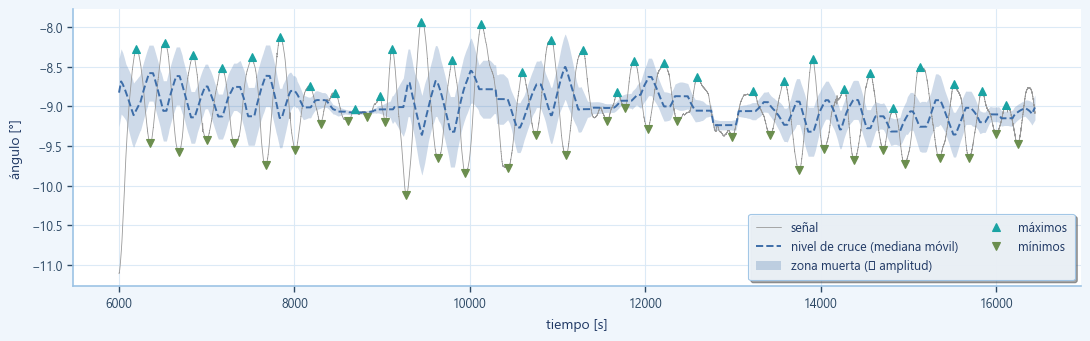

In [3]:
# ----- no paramétrico robusto: nivel local + zona muerta escalada con la amplitud -----
def baseline_local(t, x, ventana_s):
    """Nivel de cruce = mediana móvil (~1 período). Sigue la deriva del equilibrio
    entre tramos. NO suaviza la señal: los picos se leen del dato crudo."""
    if not ventana_s:
        return np.full_like(x, np.median(x))
    dt = np.median(np.diff(t)); n = max(3, int(round(ventana_s / dt)))
    return pd.Series(x).rolling(n, center=True, min_periods=1).median().to_numpy()

def envolvente_amplitud(t, x, base, ventana_s):
    """Amplitud reciente = mediana móvil de |x - base| (~1 período). Robusta: NO colapsa
    ante un pico chico aislado, porque la mediana del ciclo incluye las oscilaciones grandes."""
    dt = np.median(np.diff(t)); n = max(3, int(round(ventana_s / dt)))
    return pd.Series(np.abs(np.asarray(x) - np.asarray(base))).rolling(n, center=True, min_periods=1).median().to_numpy()

def cruces(t, x, base, banda):
    """Cruces de (x - base) = 0 con histéresis de ancho 'banda' (escalar o array por muestra)
    e interpolación lineal a sub-muestra. La zona muerta ±banda descarta las ondulaciones
    sub-amplitud cerca de la línea media; los cruces resultantes ALTERNAN por construcción
    (por eso no hace falta fusionar)."""
    d = np.asarray(x) - np.asarray(base); ba = np.broadcast_to(banda, d.shape)
    s = np.zeros(len(d), int); s[d > ba] = 1; s[d < -ba] = -1
    # forward-fill del estado: dentro de la zona muerta se conserva el estado anterior
    idx = np.where(s != 0, np.arange(len(s)), -1); np.maximum.accumulate(idx, out=idx)
    sf = np.zeros(len(d), int); ok = idx >= 0; sf[ok] = s[idx[ok]]
    k = np.flatnonzero((sf[:-1] != 0) & (sf[1:] != 0) & (sf[:-1] != sf[1:]))   # transiciones de signo
    tc, dc = [], []
    for i in k:
        x0, x1 = d[i], d[i + 1]
        frac = 0.0 if x1 == x0 else np.clip(x0 / (x0 - x1), 0.0, 1.0)   # cruce de d=0
        tc.append(float(t[i] + frac * (t[i + 1] - t[i]))); dc.append(+1 if sf[i + 1] > 0 else -1)
    return np.array(tc), np.array(dc, int)

def extremos(ts, xs, t_cr, d_cr, v=VENTANA_EXTREMO_S):
    """Un extremo por cada intervalo entre cruces; valor por mediana local (robusto al ruido)."""
    te, xe, tipo = [], [], []
    for i in range(len(t_cr) - 1):
        a, b = t_cr[i], t_cr[i + 1]; es_max = (d_cr[i] == +1); w = (ts >= a) & (ts <= b)
        if w.sum() < 10: continue
        tw, xw = ts[w], xs[w]; tg = np.arange(a + v, b - v + 1e-9, v)
        if len(tg) < 1:
            j = int(np.argmax(xw) if es_max else np.argmin(xw)); te.append(float(tw[j])); xe.append(float(xw[j]))
        else:
            md_ = np.array([np.median(xw[np.abs(tw - g) <= v]) for g in tg])
            j = int(np.argmax(md_) if es_max else np.argmin(md_)); te.append(float(tg[j])); xe.append(float(md_[j]))
        tipo.append(+1 if es_max else -1)
    return np.array(te), np.array(xe), np.array(tipo, dtype=int)

ruido = 2 * np.median(np.abs(np.diff(th)))                 # ruido muestra-a-muestra (MAD)
piso  = K_BANDA * ruido                                    # piso de la zona muerta
base  = baseline_local(t, th, BASE_LOCAL_S)
amp_env = envolvente_amplitud(t, th, base, VENT_AMP_S)     # amplitud reciente (envolvente)
banda = np.maximum(piso, FRAC_BANDA * amp_env)             # zona muerta ∝ amplitud entre picos previos
tc, dc = cruces(t, th, base, banda)
te, xe, tipo = extremos(t, th, tc, dc)
print(f"zona muerta: piso ±{piso:.4f}°  ->  ±[{banda.min():.4f}, {banda.max():.4f}]° (∝ amplitud)   "
      f"->   {len(te)} extremos ({np.sum(tipo>0)} máx, {np.sum(tipo<0)} mín)")

# vistazo: señal + nivel de cruce local + zona muerta escalada + extremos
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(t, th, lw=0.6, color="0.6", label="señal")
ax.plot(t, base, lw=1.4, ls="--", label="nivel de cruce (mediana móvil)")
ax.fill_between(t, base - banda, base + banda, alpha=0.25, lw=0, label="zona muerta (∝ amplitud)")
ax.plot(te[tipo>0], xe[tipo>0], "^", ms=6, label="máximos")
ax.plot(te[tipo<0], xe[tipo<0], "v", ms=6, label="mínimos")
ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo [°]"); ax.legend(loc="best", ncol=2); plt.show()

In [4]:
# ----- A = (pico a pico)/2  y  T = 2 * semiperÃ­odo, entre extremos consecutivos -----
dt   = np.diff(te)                 # semiperÃ­odo entre extremos consecutivos
T    = 2.0 * dt                    # perÃ­odo
A    = np.abs(np.diff(xe)) / 2.0   # amplitud = pico a pico / 2
t_mid = 0.5 * (te[1:] + te[:-1])   # tiempo del punto medio (para colorear por tiempo)

tabla = pd.DataFrame({"t_mid_s": t_mid, "A_deg": A, "A2_deg2": A**2, "T_s": T})
print(tabla.describe().loc[["min", "max", "mean"]].round(3).to_string())
tabla.head()

        t_mid_s  A_deg  A2_deg2      T_s
min    6277.733  0.046    0.002  131.200
max   16174.800  1.090    1.188  794.533
mean  11147.687  0.475    0.279  329.329


,t_mid_s,A_deg,A2_deg2,T_s
0,6277.733334,0.596290,0.355562,318.133334
1,6438.966667,0.633461,0.401273,326.800000
2,6601.733334,0.686553,0.471355,324.266666
3,6763.266666,0.607478,0.369030,321.866666
4,6922.866667,0.530131,0.281039,316.533334


In [5]:
fontsize = 12
plt.rcParams.update(
    {
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)

períodos: n = 61
mediana = 321.9 s   media = 329.3 s   desv. = 104.9 s   rango = [131.2, 794.5] s
Un pico angosto -> período casi constante (SHM amortiguado);
una distribución ancha/sesgada -> el período varía (consistente con dependencia tipo Duffing).


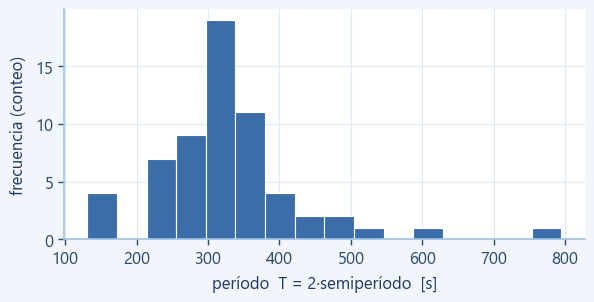

In [6]:
# ----- gráfico principal: histograma de períodos -----
fig, ax = plt.subplots(figsize=(6, 3))
fig.tight_layout()
T_rec = T[(T > 0.0) & (T < 900.0)]  # descarta valores absurdos
ax.hist(T_rec, bins="auto", edgecolor="white")   # color de barra = estilo aero
ax.set_xlabel("período  T = 2·semiperíodo  [s]")
ax.set_ylabel("frecuencia (conteo)")

print(f"períodos: n = {len(T_rec)}")
print(f"mediana = {np.median(T_rec):.1f} s   media = {np.mean(T_rec):.1f} s   "
      f"desv. = {np.std(T_rec, ddof=1):.1f} s   rango = [{T_rec.min():.1f}, {T_rec.max():.1f}] s")
print("Un pico angosto -> período casi constante (SHM amortiguado);")
print("una distribución ancha/sesgada -> el período varía (consistente con dependencia tipo Duffing).")

In [7]:
from scipy.stats import pearsonr
pearson_r, pearson_p = pearsonr(A, T)
pearson_r, pearson_p

(np.float64(0.3045110739977326), np.float64(0.017029344183797295))